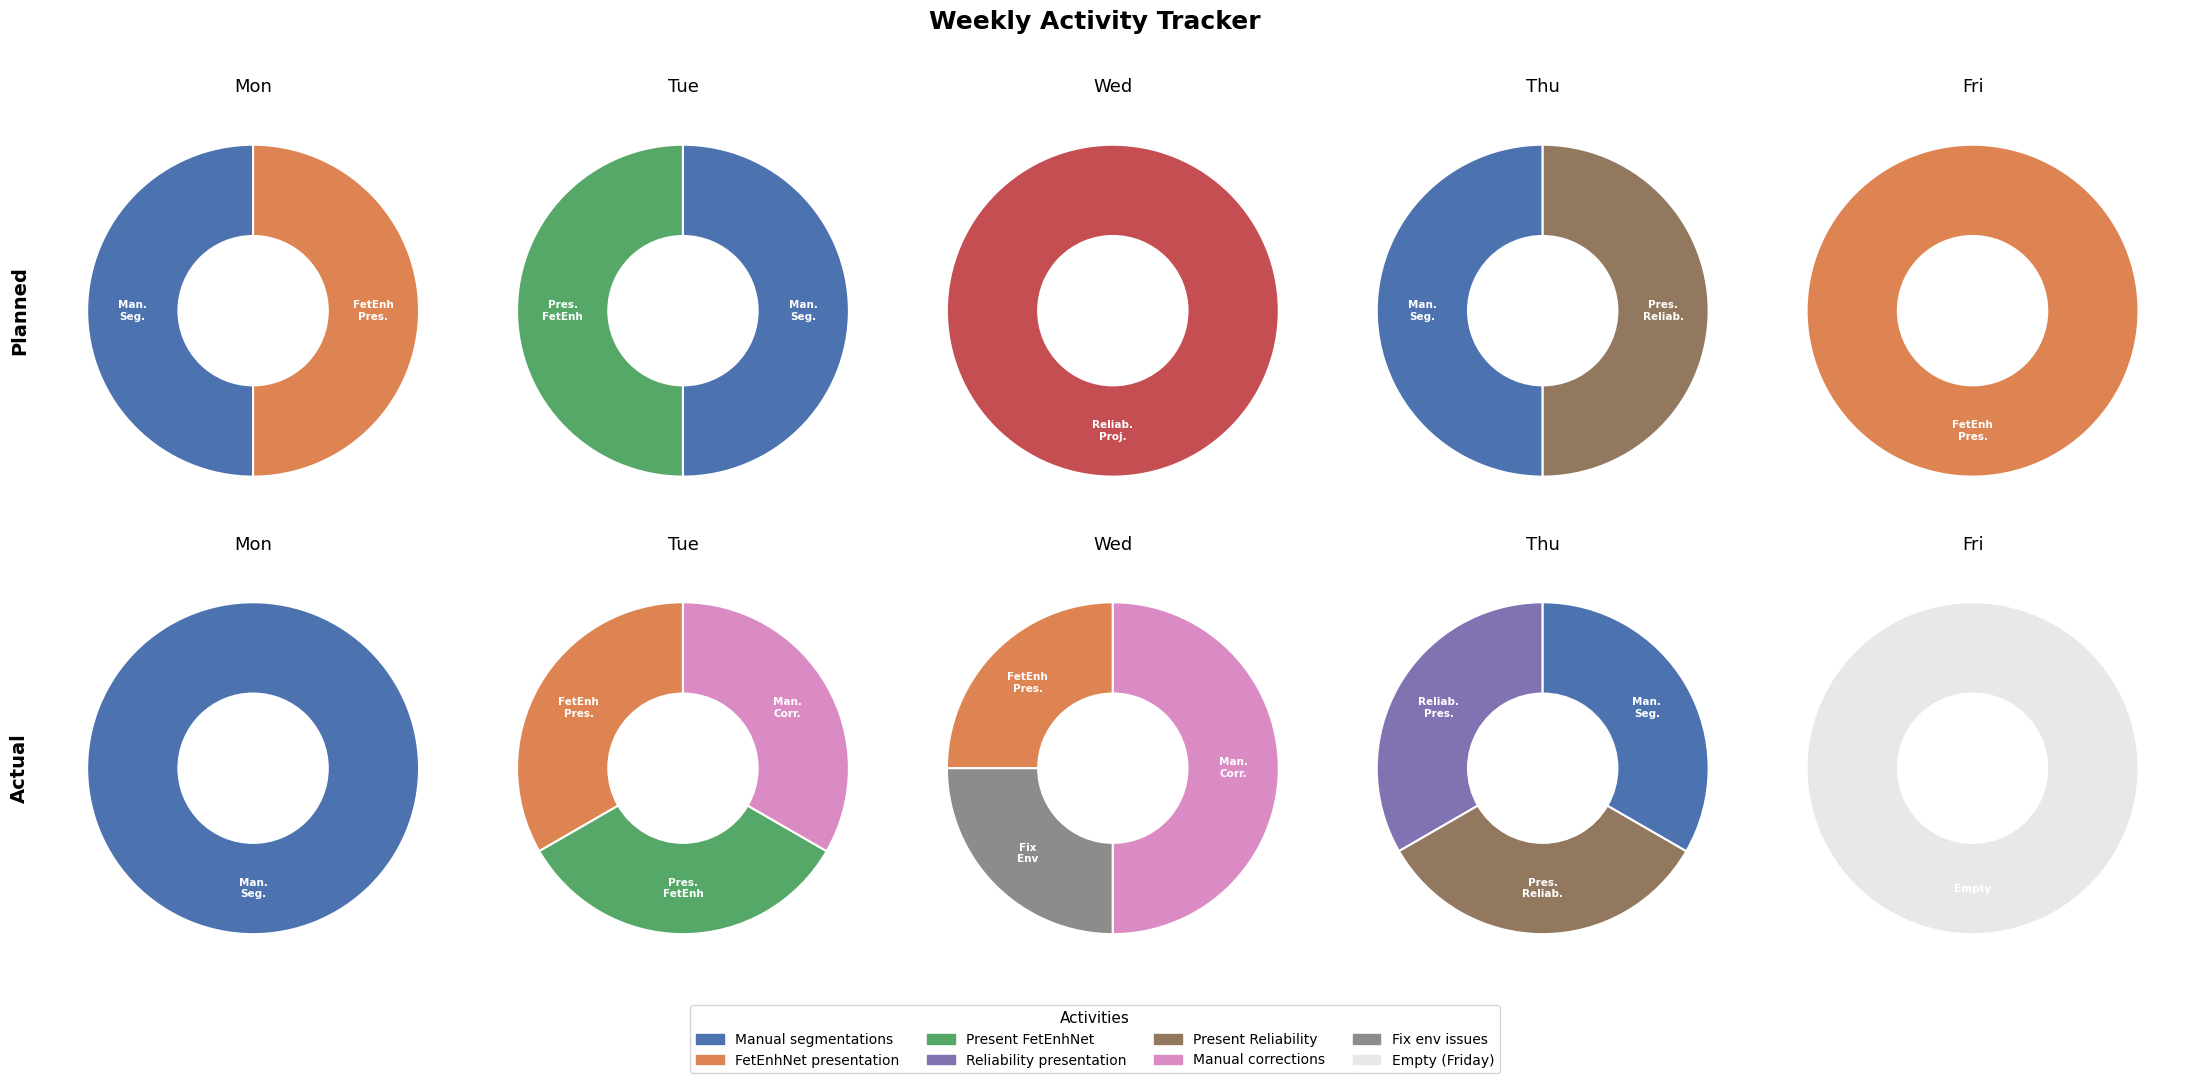

Saved → weekly_activity_tracker.png


In [2]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

ACTIVITY_COLORS = {
    "Manual segmentations":    "#4C72B0",
    "FetEnhNet presentation":  "#DD8452",
    "Present FetEnhNet":       "#55A868",
    "Reliability project":     "#C44E52",
    "Reliability presentation":"#8172B2",
    "Present Reliability":     "#937860",
    "Manual corrections":      "#DA8BC3",
    "Fix env issues":          "#8C8C8C",
    "Empty (Friday)":          "#E8E8E8",
}

ABBREV = {
    "Manual segmentations":    "Man.\nSeg.",
    "FetEnhNet presentation":  "FetEnh\nPres.",
    "Present FetEnhNet":       "Pres.\nFetEnh",
    "Reliability project":     "Reliab.\nProj.",
    "Reliability presentation":"Reliab.\nPres.",
    "Present Reliability":     "Pres.\nReliab.",
    "Manual corrections":      "Man.\nCorr.",
    "Fix env issues":          "Fix\nEnv",
    "Empty (Friday)":          "Empty",
}

def make_labels_sizes(day_activities):
    from collections import Counter
    counts = Counter(day_activities)
    labels = list(counts.keys())
    sizes  = [counts[k] for k in labels]
    colors = [ACTIVITY_COLORS[k] for k in labels]
    abbrevs = [ABBREV[k] for k in labels]
    return labels, sizes, colors, abbrevs

planned = {
    "Mon": ["Manual segmentations", "FetEnhNet presentation"],
    "Tue": ["Present FetEnhNet", "Manual segmentations"],
    "Wed": ["Reliability project", "Reliability project"],
    "Thu": ["Manual segmentations", "Present Reliability"],
    "Fri": ["FetEnhNet presentation"],
}

actual = {
    "Mon": ["Manual segmentations"],
    "Tue": ["FetEnhNet presentation", "Present FetEnhNet", "Manual corrections"],
    "Wed": ["FetEnhNet presentation", "Fix env issues", "Manual corrections", "Manual corrections"],
    "Thu": ["Reliability presentation", "Present Reliability", "Manual segmentations"],
    "Fri": ["Empty (Friday)"],
}

days = ["Mon", "Tue", "Wed", "Thu", "Fri"]

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
fig.suptitle("Weekly Activity Tracker", fontsize=18, fontweight="bold", y=1.01)

DONUT_WIDTH = 0.55  # outer=1.0, inner=0.45 → mid-ring ≈ 0.725
MID_RING = 1 - DONUT_WIDTH / 2  # 0.725

for row, (dataset, row_lbl) in enumerate(zip([planned, actual], ["Planned", "Actual"])):
    axes[row, 0].set_ylabel(row_lbl, fontsize=14, fontweight="bold", labelpad=12)
    for col, day in enumerate(days):
        ax = axes[row, col]
        labels, sizes, colors, abbrevs = make_labels_sizes(dataset[day])

        wedge_props = dict(width=DONUT_WIDTH, edgecolor="white", linewidth=1.5)
        wedges, _ = ax.pie(
            sizes,
            colors=colors,
            startangle=90,
            wedgeprops=wedge_props,
        )

        # Place abbreviated labels at the midpoint of each wedge
        for wedge, abbr in zip(wedges, abbrevs):
            angle = (wedge.theta1 + wedge.theta2) / 2
            x = MID_RING * np.cos(np.radians(angle))
            y = MID_RING * np.sin(np.radians(angle))
            ax.text(
                x, y, abbr,
                ha="center", va="center",
                fontsize=7.5, fontweight="bold",
                color="white",
                multialignment="center",
            )

        ax.set_title(day, fontsize=13, pad=8)

# Shared legend
all_used = set()
for d in {**planned, **actual}.values():
    all_used.update(d)

legend_handles = [
    mpatches.Patch(color=ACTIVITY_COLORS[a], label=a)
    for a in ACTIVITY_COLORS if a in all_used
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=4,
    fontsize=10,
    frameon=True,
    bbox_to_anchor=(0.5, -0.06),
    title="Activities",
    title_fontsize=11,
)

plt.tight_layout()
plt.savefig("weekly_activity_tracker.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → weekly_activity_tracker.png")
